## Overview
This notebook regresses a portfolio of 3 tickers against a two-factor model (Market + HML) and compares three portfolio strategies: Naive MVO, Ridge MVO and Factor Neutral.

- Tickers: `["GLD", "QQQ", "SOXX", "TLT"]`
- Risk-free rate: `^IRX` (CBOE 13-week Treasury yield)
- Data period: 10 years requested (`365 * 10` days).

## 1. SET UP LIBRARIES

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import datetime as dt
from plotnine import (
    ggplot, aes, geom_line, geom_point, geom_hline, geom_tile, geom_text,
    facet_wrap, scale_color_manual, scale_linetype_manual,
    scale_fill_gradient2, scale_y_log10, scale_x_date, scale_x_discrete, scale_y_discrete,
    labs, theme, element_text, coord_equal
)

from IPython.display import Markdown, display
from scipy import stats

## 2. INPUT PARAMETERS

In [2]:
# Portfolio specified in the new project requirements
tickers = ["GLD", "QQQ", "SOXX", "TLT"]

# Risk-free rate
rf_ticker = "^IRX"

# Define the data period by number of days OR by a specific start date.
# We use PERIOD here.
period = 365 * 10

# Leave START as None because PERIOD is being used.
start = None

if period is not None:
    start = dt.datetime.now() - dt.timedelta(days=period)

print("Period:", period, "days")
print("Start:", start)

Period: 3650 days
Start: 2016-10-01 18:54:55.227902


## 3. CONSTANT PARAMETERS

In [3]:
trading_days = 252

# Risk-aversion parameter
lam = 1.0

# Expected-return perturbation:
# 1 basis point = 0.0001
nudge = 0.01

print("Trading days:", trading_days)
print("Lambda:", lam)
print("Expected-return nudge:", nudge)

Trading days: 252
Lambda: 1.0
Expected-return nudge: 0.01


## 4. DOWNLOAD DATA

In [4]:
data_tickers = [
    *tickers,
    "^GSPC",   # S&P 500 Market Index
    "IVE",     # S&P 500 Value
    "IVW",     # S&P 500 Growth
    rf_ticker  # ^IRX
]

prices = yf.download(
    data_tickers,
    start=start,
    auto_adjust=True,
    progress=False
)["Close"]

# Remove columns that contain no data
prices = prices.dropna(axis=1, how="all")

print("Data downloaded successfully.")
print("Date range:", prices.index.min(), "to", prices.index.max())
print("Number of observations:", len(prices))

Data downloaded successfully.
Date range: 2016-10-03 00:00:00 to 2026-09-28 00:00:00
Number of observations: 2510


## 5. PREPARE RETURNS & RISK-FREE RATE

In [5]:
# Daily percentage returns
returns = prices.pct_change().dropna()

# Portfolio returns
R = returns[tickers].copy()

# ^IRX is quoted as an annualised percentage yield.
# Convert from percentage to decimal.
rf_rate = prices[rf_ticker] / 100

# Align risk-free rate with the return dates
rf_rate = rf_rate.reindex(returns.index)

# Daily risk-free rate, to match the daily returns it is subtracted from
rf_daily = rf_rate / trading_days

print("Risk-free rate prepared successfully.")
print("Daily risk-free rate:")
display(rf_daily.head())

print("\nPortfolio returns:")
display(R.head())

Risk-free rate prepared successfully.
Daily risk-free rate:


Date
2016-10-04    0.000012
2016-10-05    0.000012
2016-10-06    0.000012
2016-10-07    0.000012
2016-10-10    0.000012
Name: ^IRX, dtype: float64


Portfolio returns:


Ticker,GLD,QQQ,SOXX,TLT
Date,,,,
2016-10-04,-0.034711,-0.001518,-0.002584,-0.011695
2016-10-05,-0.001571,0.003548,0.007326,-0.004660
2016-10-06,-0.009273,-0.000505,0.005853,-0.005573
2016-10-07,0.000669,-0.002190,-0.001499,0.000673
2016-10-10,0.003508,0.006331,-0.005033,-0.005899


## 6. TWO-FACTOR MODEL

In [6]:
# Market excess return
# MKT = S&P 500 return - daily risk-free rate
returns["MKT"] = returns["^GSPC"] - rf_daily

# HML = Value - Growth
returns["HML"] = returns["IVE"] - returns["IVW"]

# Keep only the two required factors
F = returns[["MKT", "HML"]].copy()

# Align all datasets to the same dates
common_index = R.index.intersection(F.index)

R = R.loc[common_index]
F = F.loc[common_index]
rf_rate = rf_rate.loc[common_index]
rf_daily = rf_daily.loc[common_index]

print("Two-factor model constructed successfully.")

print("\nMKT and HML:")
display(F.head())

Two-factor model constructed successfully.

MKT and HML:


Ticker,MKT,HML
Date,,
2016-10-04,-0.004968,-0.001372
2016-10-05,0.004284,0.005226
2016-10-06,0.000469,-0.000538
2016-10-07,-0.003266,0.000963
2016-10-10,0.004594,-0.000130


## 7. EXPECTED RETURN VECTOR μ

Estimate mu 

In [7]:
mu = R.mean() * trading_days

print("Annualised historical mean returns:")
display(mu.to_frame("μ").round(6))

Annualised historical mean returns:


,μ
Ticker,
GLD,0.127619
QQQ,0.216992
SOXX,0.339220
TLT,-0.015052


## 8. FACTOR REGRESSIONS

In [8]:
# Store factor loadings
B = pd.DataFrame(
    index=tickers,
    columns=["MKT", "HML"],
    dtype=float
)

# Store regression alpha
alpha = pd.Series(
    index=tickers,
    dtype=float
)

# Store residuals
residuals = pd.DataFrame(
    index=R.index,
    columns=tickers,
    dtype=float
)

# Store regression statistics
regression_stats = {}

for ticker in tickers:

    # Create one dataframe containing everything needed
    regression_data = pd.concat(
        [
            R[ticker].rename("asset_return"),
            rf_daily.rename("rf"),
            F["MKT"],
            F["HML"]
        ],
        axis=1
    )

    # Remove missing or infinite observations
    regression_data = regression_data.replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    # Excess return
    y = (
        regression_data["asset_return"]
        - regression_data["rf"]
    ).values

    # Regression factors
    X_factors = regression_data[
        ["MKT", "HML"]
    ].values

    # Add intercept
    X = np.column_stack([
        np.ones(len(X_factors)),
        X_factors
    ])

    # Check that there are enough observations
    if len(y) <= X.shape[1]:
        raise ValueError(
            f"Not enough observations to regress {ticker}."
        )

    # OLS regression
    coefficients = np.linalg.lstsq(
        X,
        y,
        rcond=None
    )[0]

    # Save alpha
    alpha[ticker] = coefficients[0]

    # Save factor loadings
    B.loc[ticker, "MKT"] = coefficients[1]
    B.loc[ticker, "HML"] = coefficients[2]

    # Predicted excess return
    fitted = X @ coefficients

    # Residual
    residual = y - fitted

    # Put residuals back into the original dates
    residuals.loc[
        regression_data.index,
        ticker
    ] = residual

    # R-squared
    ss_res = np.sum(
        (y - fitted) ** 2
    )

    ss_tot = np.sum(
        (y - y.mean()) ** 2
    )

    r_squared = 1 - ss_res / ss_tot

    regression_stats[ticker] = {
        "Observations": len(y),
        "R²": r_squared
    }


# Remove rows where residuals are missing
residuals = residuals.dropna()

print("Regression alpha:")
display(alpha.to_frame("Alpha").round(6))

print("\nFactor loading matrix B:")
display(B.round(6))

print("\nRegression statistics:")
display(pd.DataFrame(regression_stats).T.round(6))

Regression alpha:


,Alpha
GLD,0.000349
QQQ,0.000137
SOXX,0.000418
TLT,-0.000124



Factor loading matrix B:


,MKT,HML
GLD,0.074711,-0.105600
QQQ,1.020523,-0.572290
SOXX,1.352178,-0.755944
TLT,-0.162337,-0.183826



Regression statistics:


,Observations,R²
GLD,2507.0,0.018117
QQQ,2507.0,0.956814
SOXX,2507.0,0.704441
TLT,2507.0,0.041672


## 9. FACTOR COVARIANCE Ω

In [9]:
Omega_daily = F.cov()

print("Daily factor covariance Ω:")
display(Omega_daily.round(8))

# Annualised factor covariance
Omega = Omega_daily * trading_days

print("\nAnnualised factor covariance Ω:")
display(Omega.round(6))

Daily factor covariance Ω:


Ticker,MKT,HML
Ticker,,
MKT,0.000130,-0.000032
HML,-0.000032,0.000063



Annualised factor covariance Ω:


Ticker,MKT,HML
Ticker,,
MKT,0.032714,-0.008110
HML,-0.008110,0.015961


## 10. RESIDUAL COVARIANCE D

In [10]:
D_daily = residuals.cov()

# Annualise
D = D_daily * trading_days

print("Annualised residual covariance D:")
display(D.round(6))

Annualised residual covariance D:


,GLD,QQQ,SOXX,TLT
GLD,0.026479,0.000010,0.002051,0.006060
QQQ,0.000010,0.002201,0.003962,0.000191
SOXX,0.002051,0.003962,0.035879,-0.000273
TLT,0.006060,0.000191,-0.000273,0.021098


## 11. RECONSTRUCT Σ

In [11]:
B_np = B.values
Omega_np = Omega.values
D_np = D.values

Sigma = (
    B_np @ Omega_np @ B_np.T
    + D_np
)

Sigma = pd.DataFrame(
    Sigma,
    index=tickers,
    columns=tickers
)

print("Reconstructed annualised covariance matrix Σ:")
display(Sigma.round(6))

Reconstructed annualised covariance matrix Σ:


,GLD,QQQ,SOXX,TLT
GLD,0.026967,0.004690,0.008247,0.005946
QQQ,0.004690,0.050972,0.068542,-0.002782
SOXX,0.008247,0.068542,0.121393,-0.004215
TLT,0.005946,-0.002782,-0.004215,0.022015


## 12. Estimate the inputs and assemble equation Σ = BΩBᵀ + D

In [12]:
display(Markdown(
    r"""
    ### Two-Factor Covariance Model

    The covariance matrix is reconstructed using:

    $$\Sigma = B\Omega B^{T} + D$$

    where:

    - $\Sigma$ = estimated covariance matrix of portfolio asset returns
    - $B$ = factor-loading matrix
    - $\Omega$ = factor covariance matrix
    - $D$ = residual/idiosyncratic covariance matrix
    """
))

print("=" * 60)
print("EXPECTED RETURN VECTOR μ")
print("=" * 60)
display(mu.to_frame("Annualised μ").round(6))

print("=" * 60)
print("FACTOR LOADING MATRIX B")
print("=" * 60)
display(B.round(6))

print("=" * 60)
print("REGRESSION ALPHA")
print("=" * 60)
display(alpha.to_frame("Alpha").round(6))

print("=" * 60)
print("FACTOR COVARIANCE MATRIX Ω")
print("=" * 60)
display(Omega.round(6))

print("=" * 60)
print("RESIDUAL COVARIANCE MATRIX D")
print("=" * 60)
display(D.round(6))

print("=" * 60)
print("RECONSTRUCTED COVARIANCE MATRIX Σ")
print("=" * 60)
display(Sigma.round(6))


    ### Two-Factor Covariance Model

    The covariance matrix is reconstructed using:

    $$\Sigma = B\Omega B^{T} + D$$

    where:

    - $\Sigma$ = estimated covariance matrix of portfolio asset returns
    - $B$ = factor-loading matrix
    - $\Omega$ = factor covariance matrix
    - $D$ = residual/idiosyncratic covariance matrix
    

EXPECTED RETURN VECTOR μ


,Annualised μ
Ticker,
GLD,0.127619
QQQ,0.216992
SOXX,0.339220
TLT,-0.015052


FACTOR LOADING MATRIX B


,MKT,HML
GLD,0.074711,-0.105600
QQQ,1.020523,-0.572290
SOXX,1.352178,-0.755944
TLT,-0.162337,-0.183826


...

Ticker,MKT,HML
Ticker,,
MKT,0.032714,-0.008110
HML,-0.008110,0.015961


RESIDUAL COVARIANCE MATRIX D


,GLD,QQQ,SOXX,TLT
GLD,0.026479,0.000010,0.002051,0.006060
QQQ,0.000010,0.002201,0.003962,0.000191
SOXX,0.002051,0.003962,0.035879,-0.000273
TLT,0.006060,0.000191,-0.000273,0.021098


RECONSTRUCTED COVARIANCE MATRIX Σ


,GLD,QQQ,SOXX,TLT
GLD,0.026967,0.004690,0.008247,0.005946
QQQ,0.004690,0.050972,0.068542,-0.002782
SOXX,0.008247,0.068542,0.121393,-0.004215
TLT,0.005946,-0.002782,-0.004215,0.022015


## 13. NAIVE MVO

In [ ]:
Sigma_np = Sigma.values
mu_np = mu.values
n = len(tickers)

ones = np.ones(n)

# Fully-invested KKT system
KKT_naive = np.block([
    [lam * Sigma_np, ones.reshape(-1, 1)],
    [ones.reshape(1, -1), np.zeros((1, 1))]
])

rhs_naive = np.concatenate([
    mu_np,
    [1.0]
])

solution_naive = np.linalg.solve(
    KKT_naive,
    rhs_naive
)

w_naive = solution_naive[:n]

w_naive = pd.Series(
    w_naive,
    index=tickers,
    name="Naive MVO"
)

print("Naive MVO weights:")
display(w_naive.to_frame().round(6))

print("Weight sum:", w_naive.sum())
print("Gross exposure:", w_naive.abs().sum())

Naive MVO weights:


,Naive MVO
GLD,2.770893
QQQ,-0.130034
SOXX,2.068838
TLT,-3.709697


Weight sum: 1.0
Gross exposure: 8.679462530600428


## 14. NAIVE MVO SENSITIVITY

In [36]:
mu_nudged = mu_np.copy()

# Nudge QQQ expected return by exactly 1%
mu_nudged[1] += nudge

rhs_nudged = np.concatenate([
    mu_nudged,
    [1.0]
])

solution_nudged = np.linalg.solve(
    KKT_naive,
    rhs_nudged
)

w_naive_nudged = pd.Series(
    solution_nudged[:n],
    index=tickers,
    name="Nudged"
)

weight_swing_naive = w_naive_nudged - w_naive

turnover_naive = (
    0.5 * weight_swing_naive.abs().sum()
)

print("Original weights:")
display(w_naive.to_frame())

print("\nNudged weights (+1% QQQ):")
display(w_naive_nudged.to_frame())

print("\nWeight changes:")
display(weight_swing_naive.to_frame("Weight Change"))

print("\nL2 weight swing:",
      np.linalg.norm(weight_swing_naive))

print("Turnover:",
      turnover_naive)

Original weights:


,Naive MVO
GLD,2.770893
QQQ,-0.130034
SOXX,2.068838
TLT,-3.709697



Nudged weights (+1% QQQ):


,Nudged
GLD,2.661554
QQQ,0.535804
SOXX,1.661591
TLT,-3.858949



Weight changes:


,Weight Change
GLD,-0.109339
QQQ,0.665838
SOXX,-0.407246
TLT,-0.149252



L2 weight swing: 0.8021353038851823
Turnover: 0.6658378711306416


## 15. RIDGE MVO

In [15]:
etas = [
    0.00,
    0.001,
    0.005,
    0.01,
    0.05,
    0.10,
    0.50,
    1.00
]

ridge_results = []

ridge_weights = {}

for eta in etas:

    # Ridge-regularised covariance term
    ridge_matrix = (
        lam * Sigma_np
        + eta * np.eye(n)
    )

    KKT_ridge = np.block([
        [ridge_matrix, ones.reshape(-1, 1)],
        [ones.reshape(1, -1), np.zeros((1, 1))]
    ])

    # Original μ
    rhs_original = np.concatenate([
        mu_np,
        [1.0]
    ])

    sol_original = np.linalg.solve(
        KKT_ridge,
        rhs_original
    )

    w_before = sol_original[:n]

    # Perturbed μ
    rhs_perturbed = np.concatenate([
        mu_nudged,
        [1.0]
    ])

    sol_perturbed = np.linalg.solve(
        KKT_ridge,
        rhs_perturbed
    )

    w_after = sol_perturbed[:n]

    weight_change = w_after - w_before

    swing = np.linalg.norm(weight_change)

    turnover = 0.5 * np.abs(weight_change).sum()

    ridge_weights[eta] = pd.Series(
        w_before,
        index=tickers
    )

    ridge_results.append({
        "eta": eta,
        "weight_swing": swing,
        "turnover": turnover,
        "gross_exposure": np.abs(w_before).sum()
    })

ridge_results = pd.DataFrame(ridge_results)

print("Ridge sensitivity results:")
display(ridge_results.round(6))

Ridge sensitivity results:


,eta,weight_swing,turnover,gross_exposure
0,0.000,0.802135,0.665838,8.679463
1,0.001,0.730762,0.607221,8.247862
2,0.005,0.539140,0.449645,7.123054
3,0.010,0.406278,0.340138,6.245267
4,0.050,0.137607,0.117140,3.539047
5,0.100,0.075809,0.065042,2.511132
6,0.500,0.016744,0.014486,1.074402
7,1.000,0.008507,0.007366,1.000000


## 16. SELECT RIDGE PORTFOLIO

In [16]:
selected_eta = 0.10

w_ridge = ridge_weights[selected_eta].copy()
w_ridge.name = "Ridge MVO"

print(f"Selected ridge parameter η = {selected_eta}")
display(w_ridge.to_frame().round(6))

Selected ridge parameter η = 0.1


,Ridge MVO
GLD,0.324158
QQQ,0.419924
SOXX,1.011485
TLT,-0.755566


## 17. RIDGE SENSITIVITY PLOT

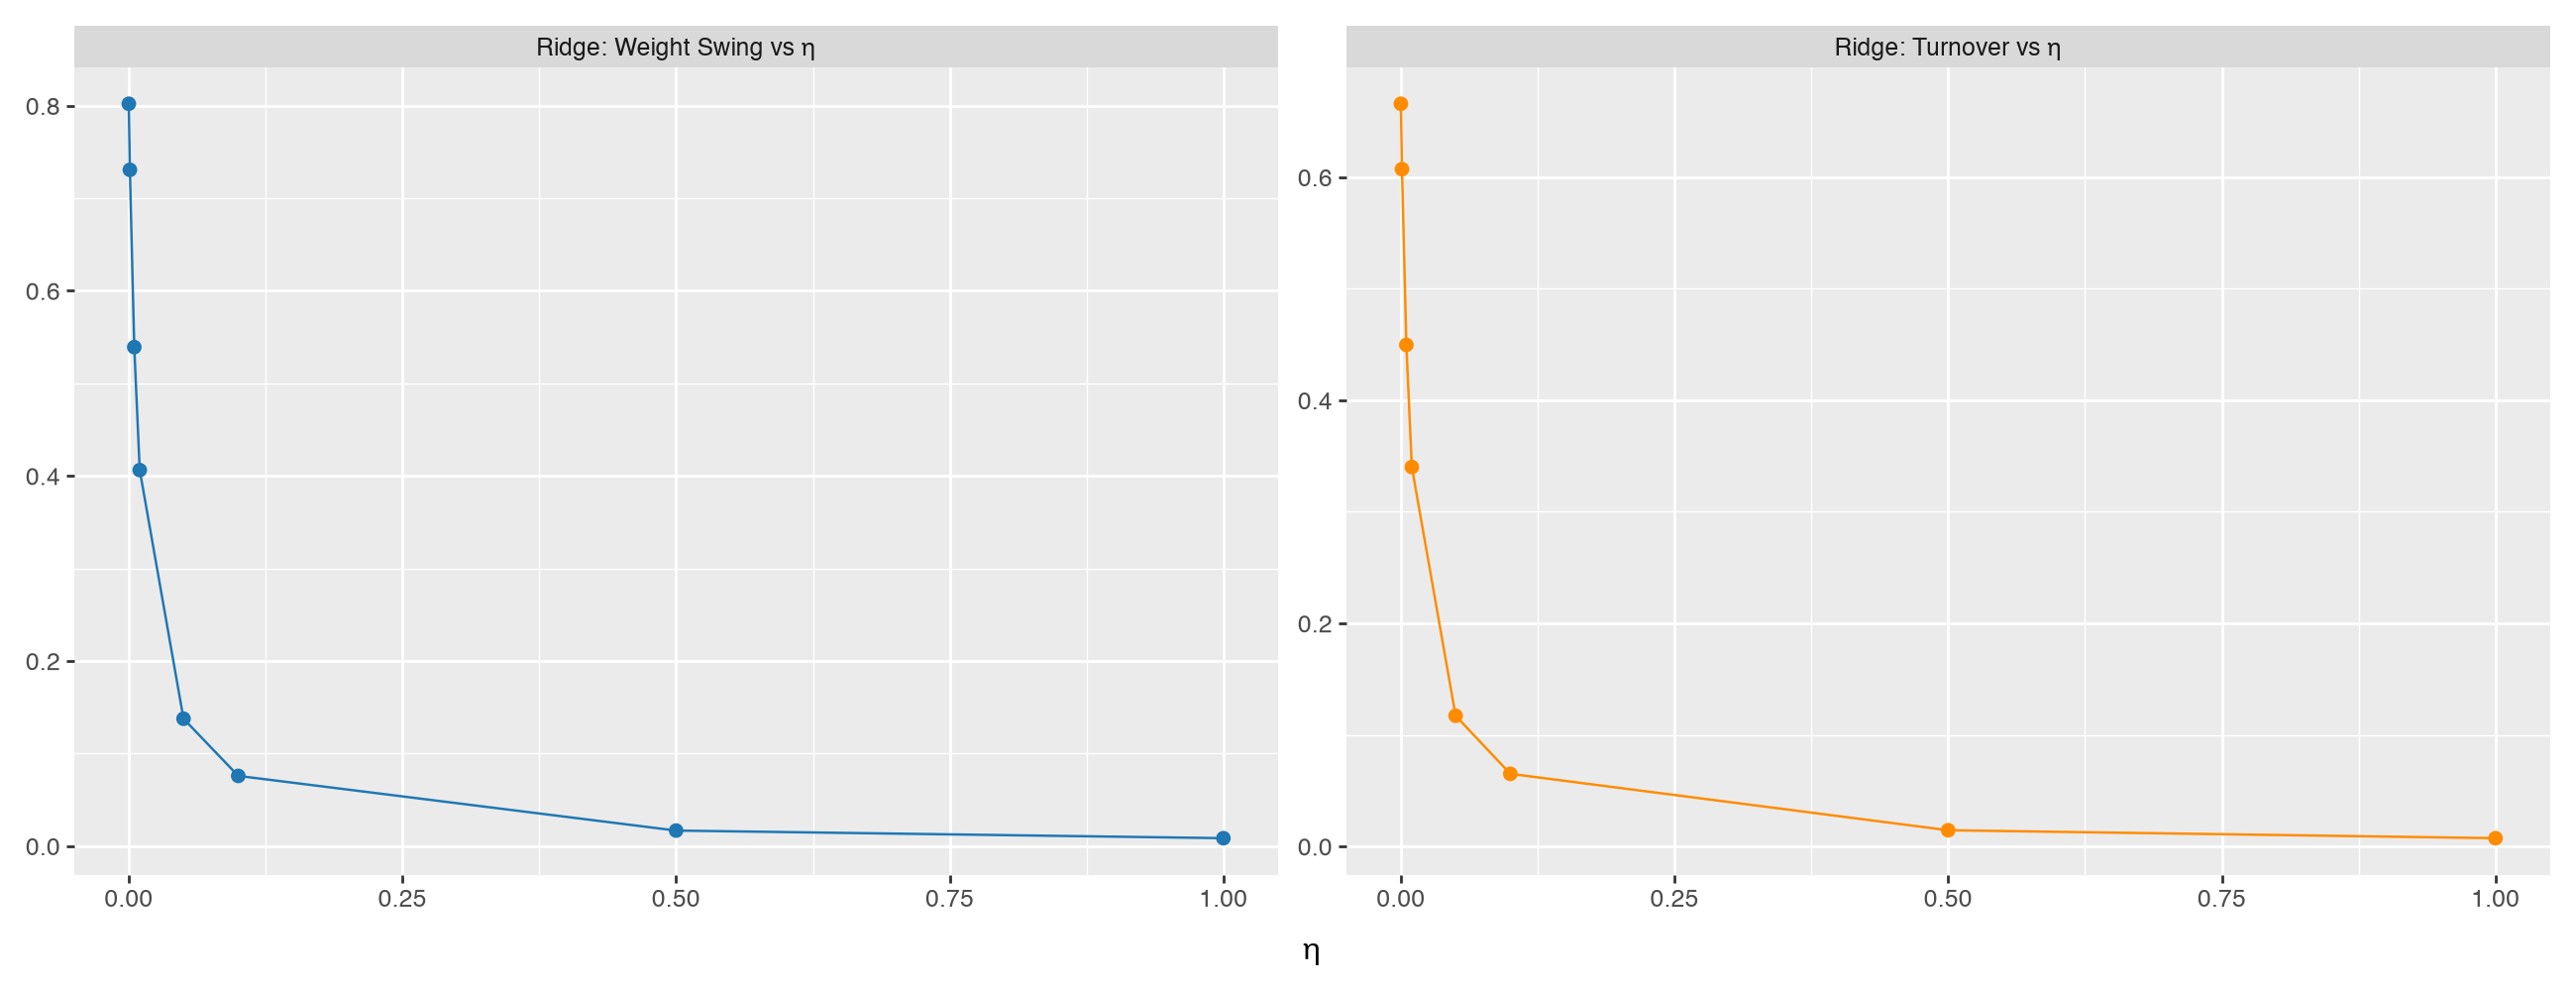

In [17]:
ridge_plot_data = ridge_results[["eta", "weight_swing", "turnover"]].melt(
    id_vars="eta",
    var_name="Metric",
    value_name="Value"
)

ridge_plot_data["Metric"] = pd.Categorical(
    ridge_plot_data["Metric"].map({
        "weight_swing": "Ridge: Weight Swing vs η",
        "turnover": "Ridge: Turnover vs η"
    }),
    categories=["Ridge: Weight Swing vs η", "Ridge: Turnover vs η"]
)

display(
    ggplot(ridge_plot_data, aes("eta", "Value", color="Metric"))
    + geom_line()
    + geom_point(size=2)
    + facet_wrap("~Metric", scales="free_y")
    + scale_color_manual(values=["#1f77b4", "darkorange"])
    + labs(x="η", y="")
    + theme(figure_size=(13, 5), legend_position="none")
)

## 18. FACTOR-NEUTRAL PORTFOLIO

In [18]:
alpha_np = alpha.values
B_np = B.values

# Constraints:
# 1) Fully invested: 1'w = 1
# 2) MKT neutral: B_MKT'w = 0
# 3) HML neutral: B_HML'w = 0

C = np.column_stack([
    np.ones(n),
    B_np
])

d = np.concatenate([
    [1.0],
    np.zeros(B_np.shape[1])
])

# KKT system
KKT_fn = np.block([
    [lam * D_np, C],
    [C.T, np.zeros((C.shape[1], C.shape[1]))]
])

rhs_fn = np.concatenate([
    alpha_np,
    d
])

solution_fn = np.linalg.solve(
    KKT_fn,
    rhs_fn
)

w_fn = pd.Series(
    solution_fn[:n],
    index=tickers,
    name="Factor Neutral"
)

print("Factor-neutral portfolio:")
display(w_fn.to_frame().round(6))

print("\nWeight sum:")
print(w_fn.sum())

print("\nFactor exposures:")
factor_exposures_fn = B.T @ w_fn
display(factor_exposures_fn.to_frame("Exposure").round(8))

print("\nGross exposure:")
print(w_fn.abs().sum())

Factor-neutral portfolio:


,Factor Neutral
GLD,1.249740
QQQ,0.607826
SOXX,-0.563140
TLT,-0.294426



Weight sum:
0.9999999999999998

Factor exposures:


,Exposure
MKT,-0.0
HML,-0.0



Gross exposure:
2.7151321603315957


## 19. VERIFY FACTOR NEUTRALITY

In [19]:
print("Bᵀw:")
print(factor_exposures_fn)

print("\nMaximum absolute factor exposure:",
      np.abs(factor_exposures_fn).max())

assert np.isclose(w_fn.sum(), 1.0)

assert np.allclose(
    B.T @ w_fn,
    0,
    atol=1e-6
)

print("\nFactor-neutrality constraints satisfied.")

Bᵀw:
MKT   -4.115129e-17
HML   -4.741762e-17
dtype: float64

Maximum absolute factor exposure: 4.741762180251687e-17

Factor-neutrality constraints satisfied.


## 20. STRATEGY WEIGHTS

In [20]:
strategy_weights = pd.DataFrame({
    "Naive MVO": w_naive,
    "Ridge MVO": w_ridge,
    "Factor Neutral": w_fn
})

display(strategy_weights.round(6))

,Naive MVO,Ridge MVO,Factor Neutral
GLD,2.770893,0.324158,1.249740
QQQ,-0.130034,0.419924,0.607826
SOXX,2.068838,1.011485,-0.563140
TLT,-3.709697,-0.755566,-0.294426


## 21. COMMON BENCHMARK

In [21]:
benchmark_weights = pd.Series(
    1 / n,
    index=tickers,
    name="Equal Weight Benchmark"
)

print("Benchmark weights:")
display(benchmark_weights.to_frame())

Benchmark weights:


,Equal Weight Benchmark
GLD,0.25
QQQ,0.25
SOXX,0.25
TLT,0.25


## 22. TRACKING ERROR

In [22]:
tracking_results = []

for strategy in strategy_weights.columns:

    w = strategy_weights[strategy]

    active_weights = w - benchmark_weights

    TE2 = (
        active_weights.values
        @ Sigma_np
        @ active_weights.values
    )

    TE = np.sqrt(TE2)

    tracking_results.append({
        "Portfolio": strategy,
        "TE²": TE2,
        "Tracking Error": TE
    })

TE_results = pd.DataFrame(tracking_results)

print("Ex-ante tracking error:")
display(TE_results.round(6))

Ex-ante tracking error:


,Portfolio,TE²,Tracking Error
0,Naive MVO,0.831031,0.911609
1,Ridge MVO,0.119579,0.345802
2,Factor Neutral,0.061211,0.247408


## 23. EQUITY CURVE

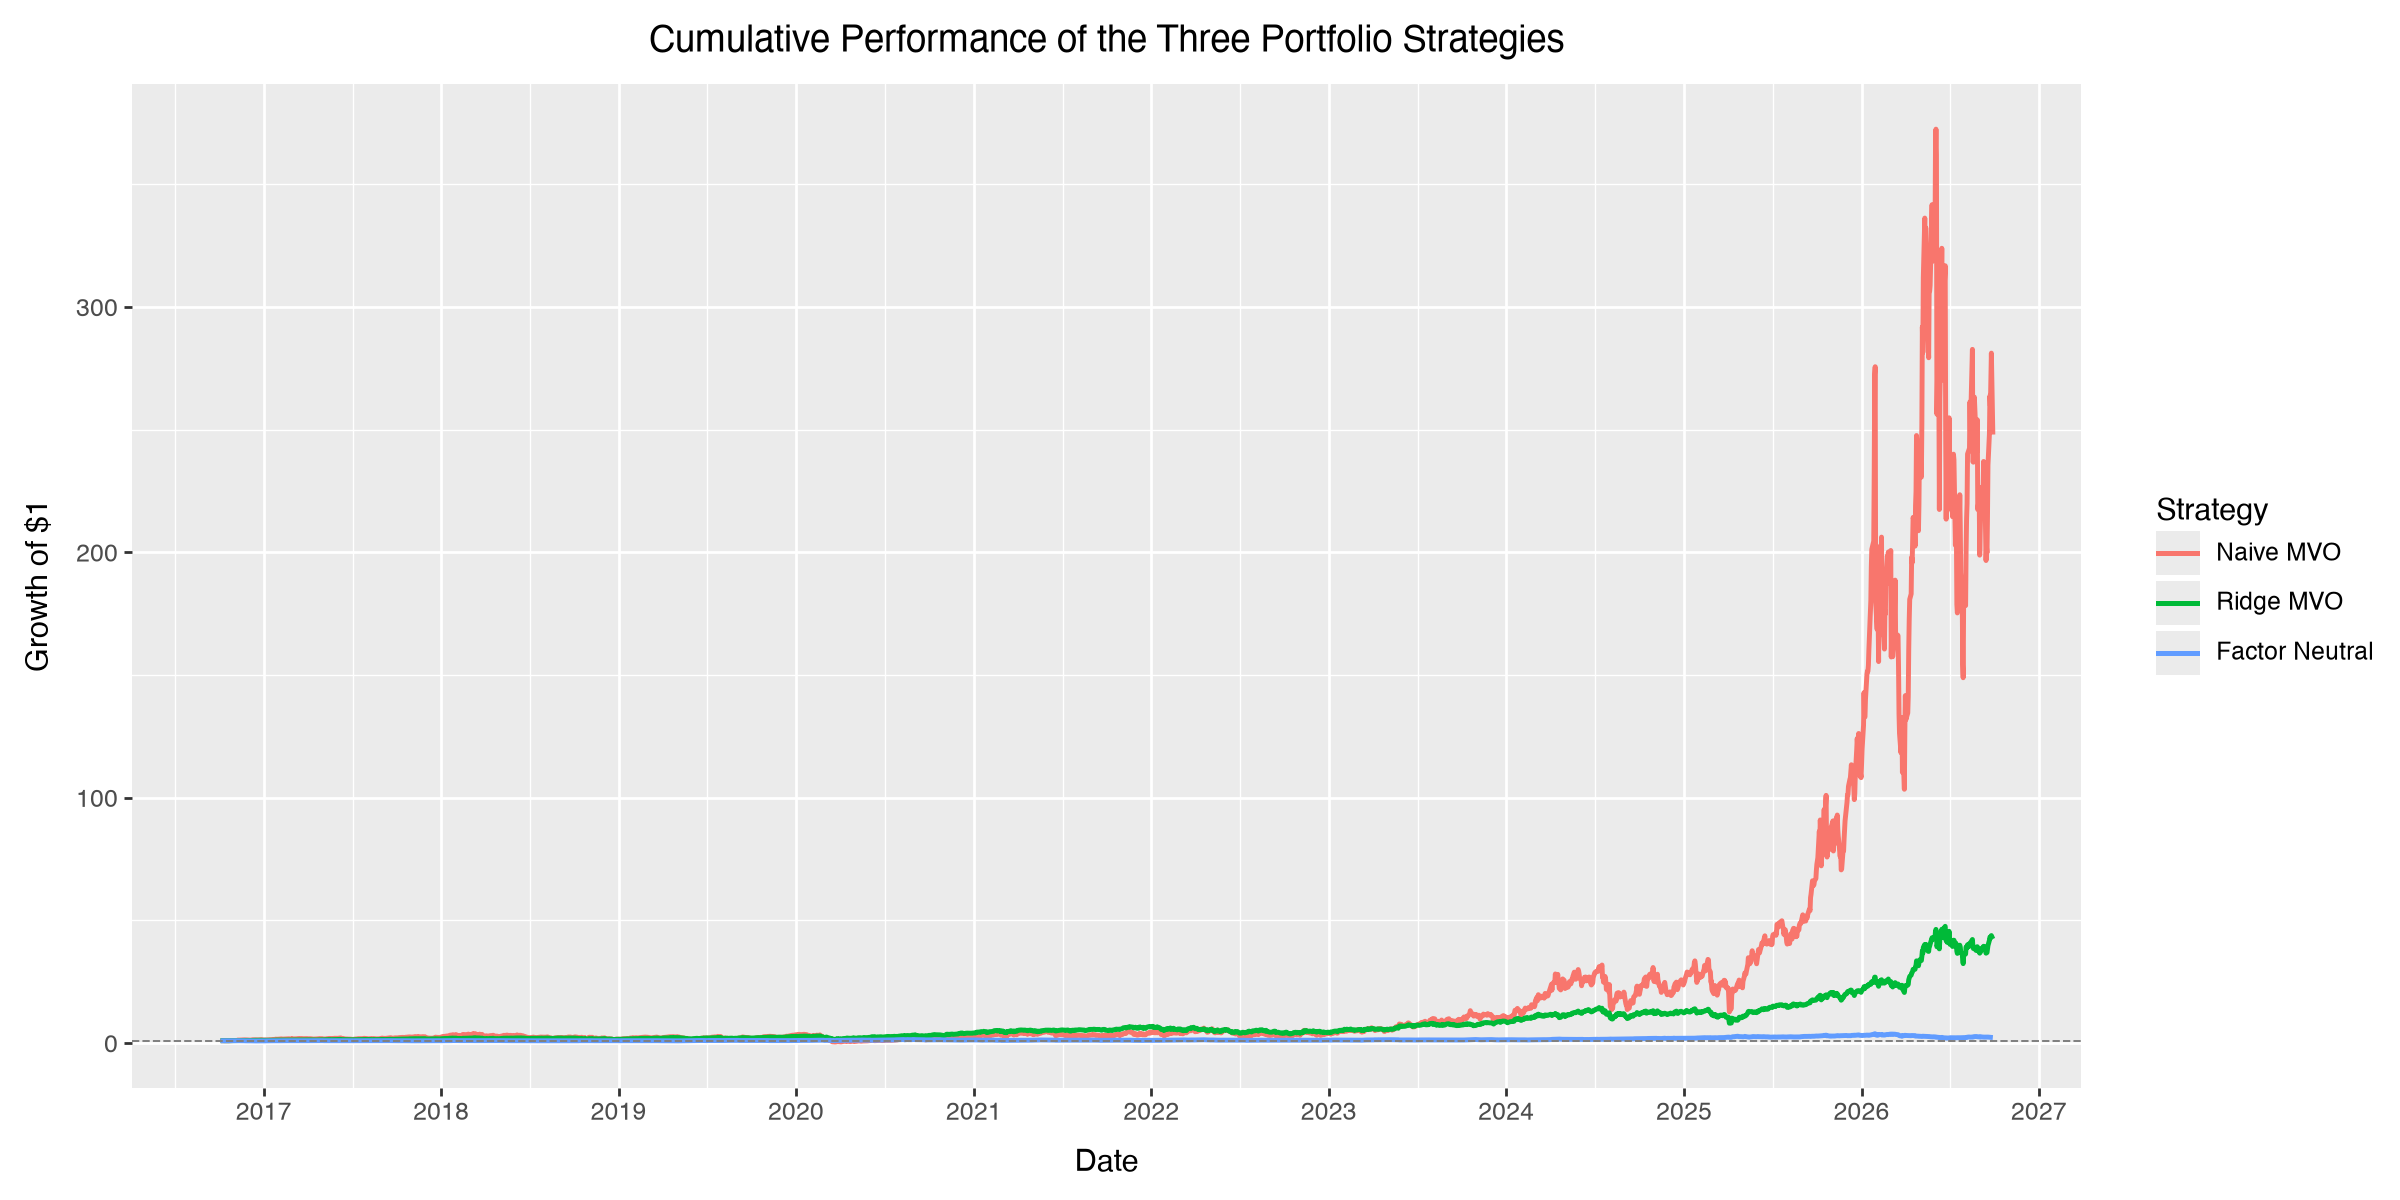

In [23]:
# Daily portfolio returns, rebalanced to the Section 20 weights every day
portfolio_returns = pd.DataFrame(index=R.index)

for strategy in strategy_weights.columns:
    portfolio_returns[strategy] = (
        R @ strategy_weights[strategy]
    )

# Cumulative growth of $1
equity = (1 + portfolio_returns).cumprod()

# Plot
equity_long = (
    equity
    .rename_axis("Date")
    .reset_index()
    .melt(id_vars="Date", var_name="Strategy", value_name="Growth")
)

# Keep the original strategy order in the legend
equity_long["Strategy"] = pd.Categorical(
    equity_long["Strategy"],
    categories=strategy_weights.columns
)

display(
    ggplot(equity_long, aes("Date", "Growth", color="Strategy"))
    + geom_line(size=1)
    + geom_hline(yintercept=1, color="gray", linetype="dashed", size=0.4)
    + scale_x_date(date_labels="%Y", date_breaks="1 year")
    + labs(
        title="Cumulative Performance of the Three Portfolio Strategies",
        x="Date",
        y="Growth of $1"
    )
    + theme(figure_size=(12, 6))
)

### Two-factor regression fit by strategy

Each chart compares a strategy's cumulative excess return with the part explained by the factors (β_MKT·MKT + β_HML·HML). The gap between the two lines is alpha plus residual noise.

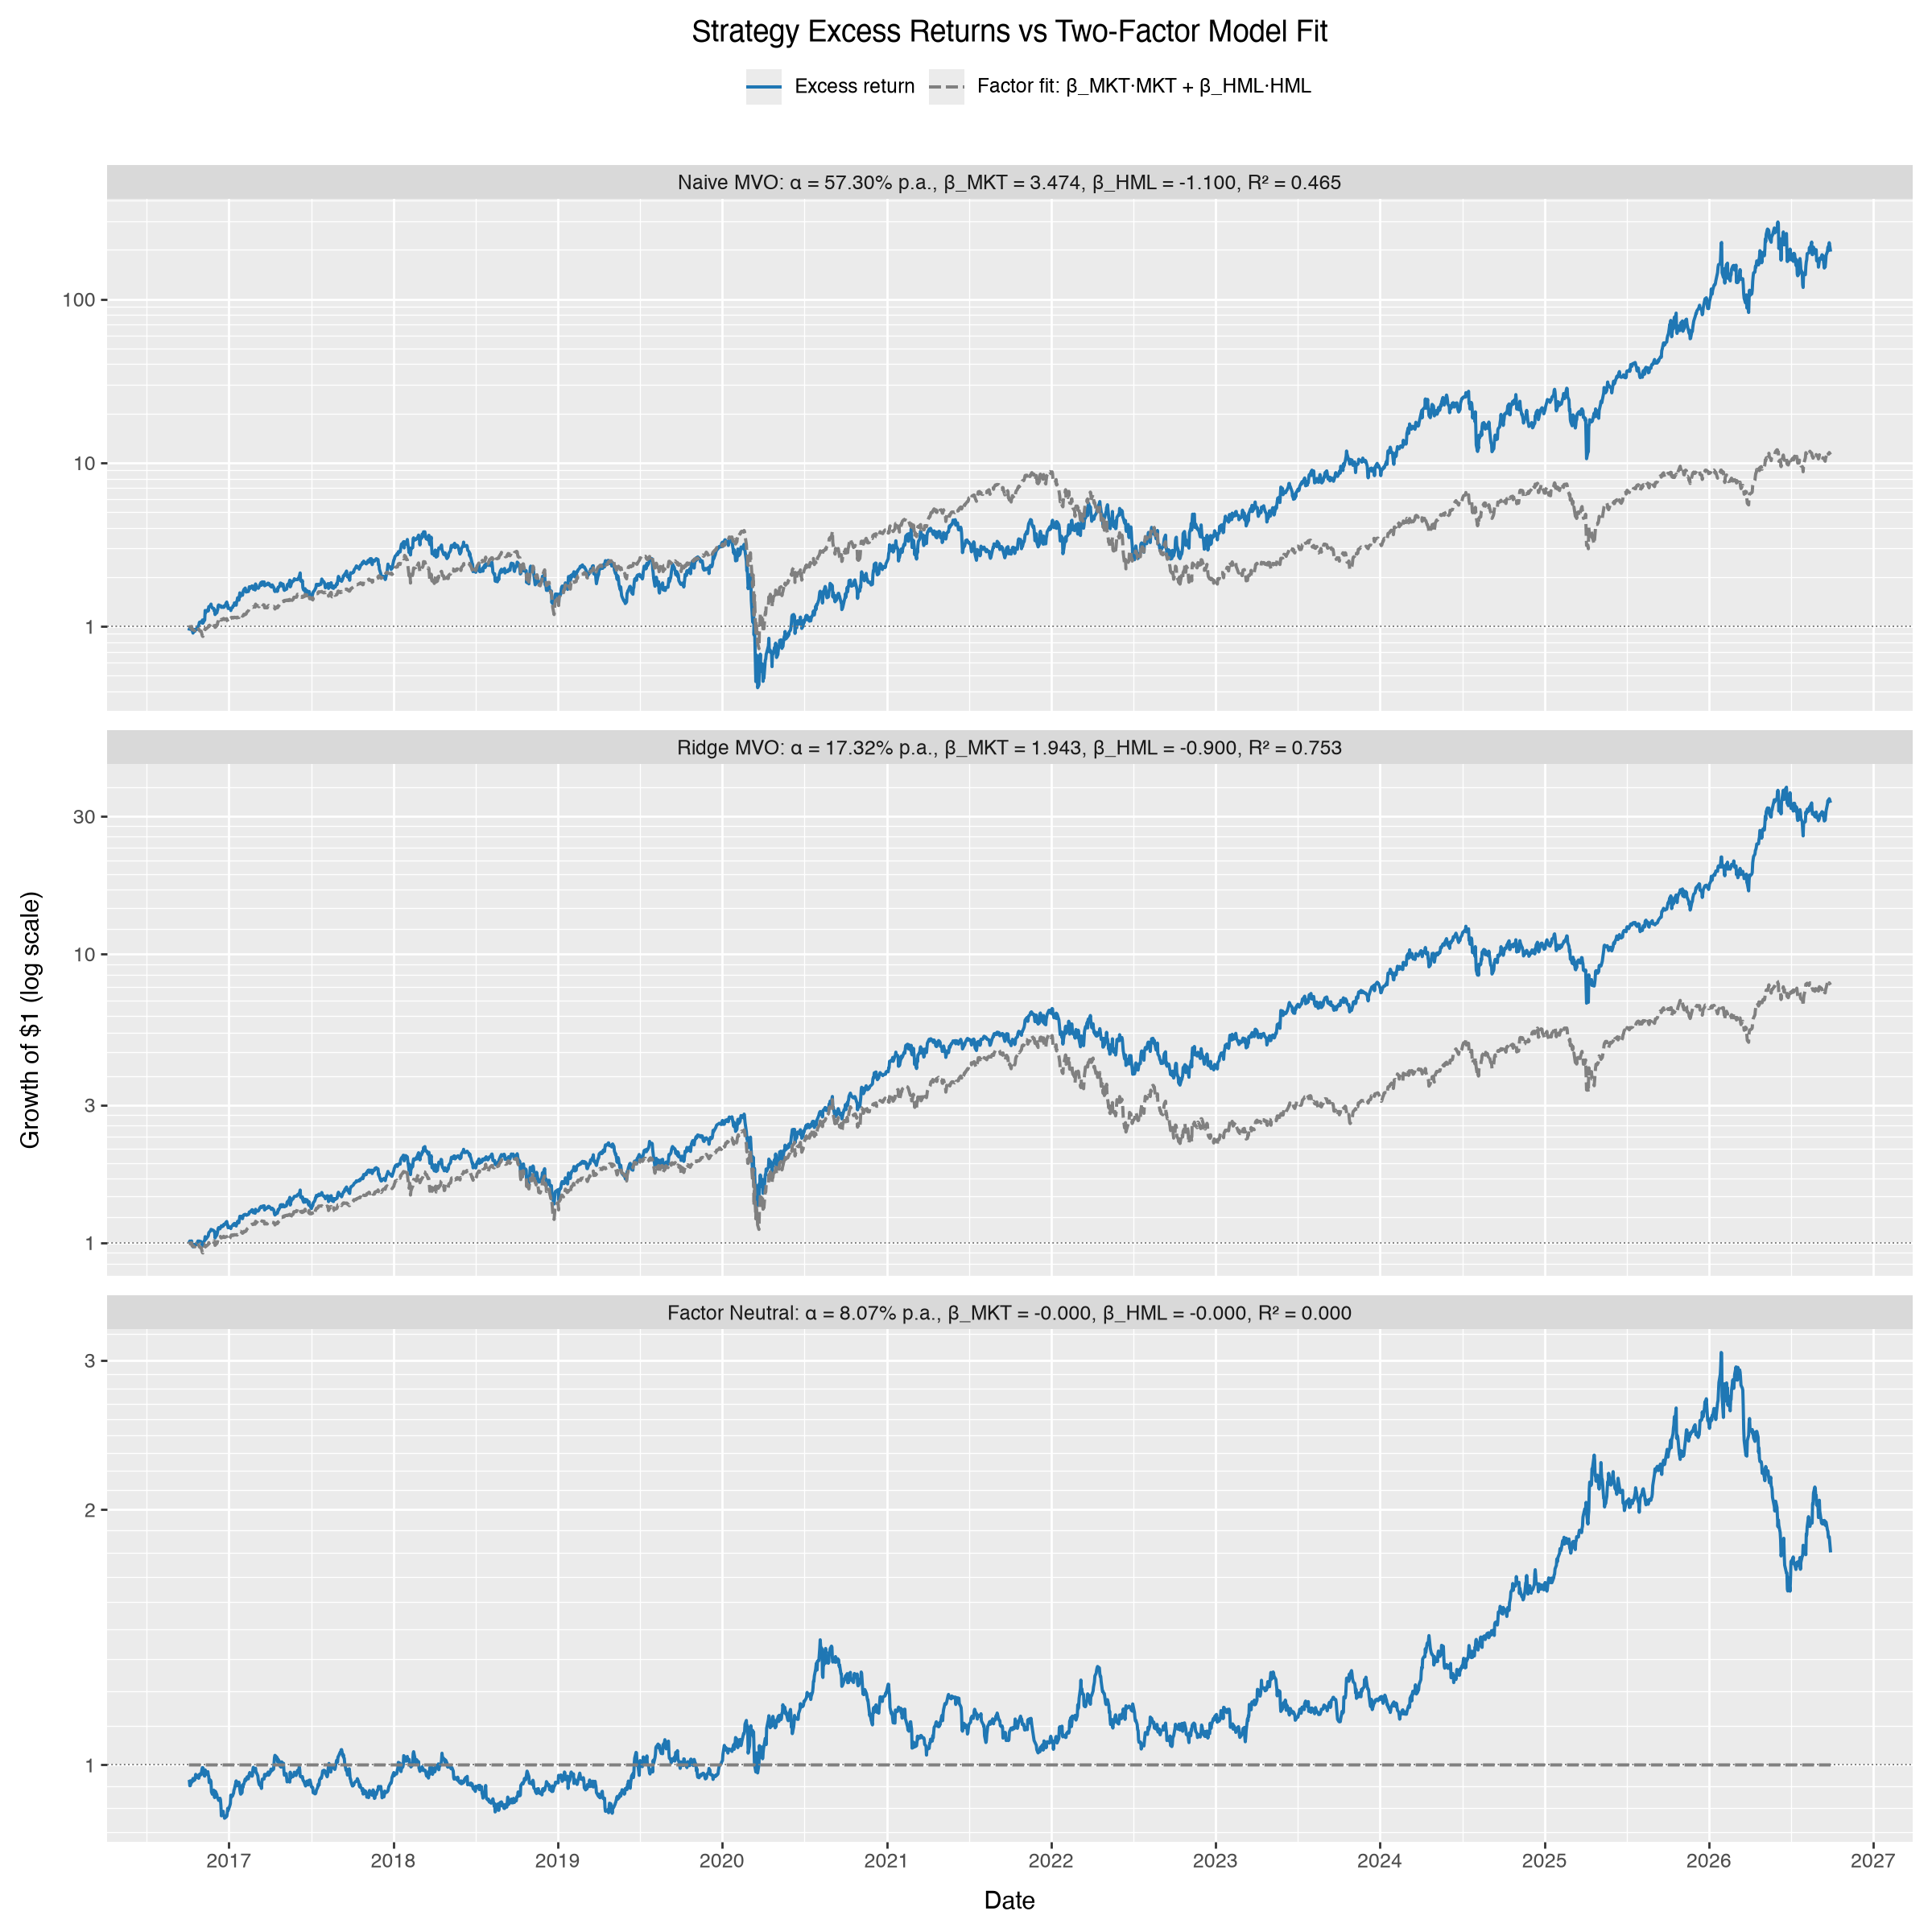

In [24]:
# Regress each strategy's excess return on the two factors:
# Rp - Rf = alpha + beta_MKT*MKT + beta_HML*HML + error
fit_data = pd.concat(
    [
        portfolio_returns,
        F["MKT"],
        F["HML"],
        rf_daily.rename("RF")
    ],
    axis=1
).replace([np.inf, -np.inf], np.nan).dropna()

X_fit = np.column_stack([
    np.ones(len(fit_data)),
    fit_data["MKT"].values,
    fit_data["HML"].values
])

fit_curves = []

for strategy in strategy_weights.columns:

    # Excess portfolio return
    y_fit = (fit_data[strategy] - fit_data["RF"]).values

    # OLS regression
    a_fit, b_mkt, b_hml = np.linalg.lstsq(X_fit, y_fit, rcond=None)[0]

    # Factor-explained return (excludes alpha and residual)
    factor_part = b_mkt * fit_data["MKT"] + b_hml * fit_data["HML"]

    # R-squared
    fitted_fit = a_fit + factor_part.values
    r2_fit = 1 - np.sum((y_fit - fitted_fit) ** 2) / np.sum((y_fit - y_fit.mean()) ** 2)

    # Panel title carries the regression statistics
    panel = (
        f"{strategy}: α = {a_fit * trading_days:.2%} p.a., "
        f"β_MKT = {b_mkt:.3f}, β_HML = {b_hml:.3f}, R² = {r2_fit:.3f}"
    )

    # Cumulative growth of $1
    curves = pd.DataFrame({
        "Excess return": (1 + pd.Series(y_fit, index=fit_data.index)).cumprod(),
        "Factor fit: β_MKT·MKT + β_HML·HML": (1 + factor_part).cumprod()
    })

    curves = (
        curves
        .rename_axis("Date")
        .reset_index()
        .melt(id_vars="Date", var_name="Series", value_name="Growth")
    )
    curves["Strategy"] = panel

    fit_curves.append(curves)

fit_curves = pd.concat(fit_curves)

# Keep the original strategy order for the panels
fit_curves["Strategy"] = pd.Categorical(
    fit_curves["Strategy"],
    categories=fit_curves["Strategy"].unique()
)

# Log scale cannot show a wiped-out (≤ 0) portfolio value
fit_curves = fit_curves[fit_curves["Growth"] > 0]

display(
    ggplot(fit_curves, aes("Date", "Growth", color="Series", linetype="Series"))
    + geom_line(size=0.8)
    + geom_hline(yintercept=1, color="gray", linetype="dotted", size=0.4)
    + facet_wrap("~Strategy", ncol=1, scales="free_y")
    + scale_x_date(date_labels="%Y", date_breaks="1 year")
    + scale_y_log10(labels=lambda values: [f"{v:g}" for v in values])
    + scale_color_manual(values=["#1f77b4", "gray"])
    + scale_linetype_manual(values=["solid", "dashed"])
    + labs(
        title="Strategy Excess Returns vs Two-Factor Model Fit",
        x="Date",
        y="Growth of $1 (log scale)",
        color="",
        linetype=""
    )
    + theme(figure_size=(12, 12), legend_position="top")
)

## 24. CORRELATION HEATMAP

Correlation matrix:


Ticker,GLD,QQQ,SOXX,TLT
Ticker,,,,
GLD,1.000,0.127,0.144,0.244
QQQ,0.127,1.000,0.871,-0.083
SOXX,0.144,0.871,1.000,-0.081
TLT,0.244,-0.083,-0.081,1.000


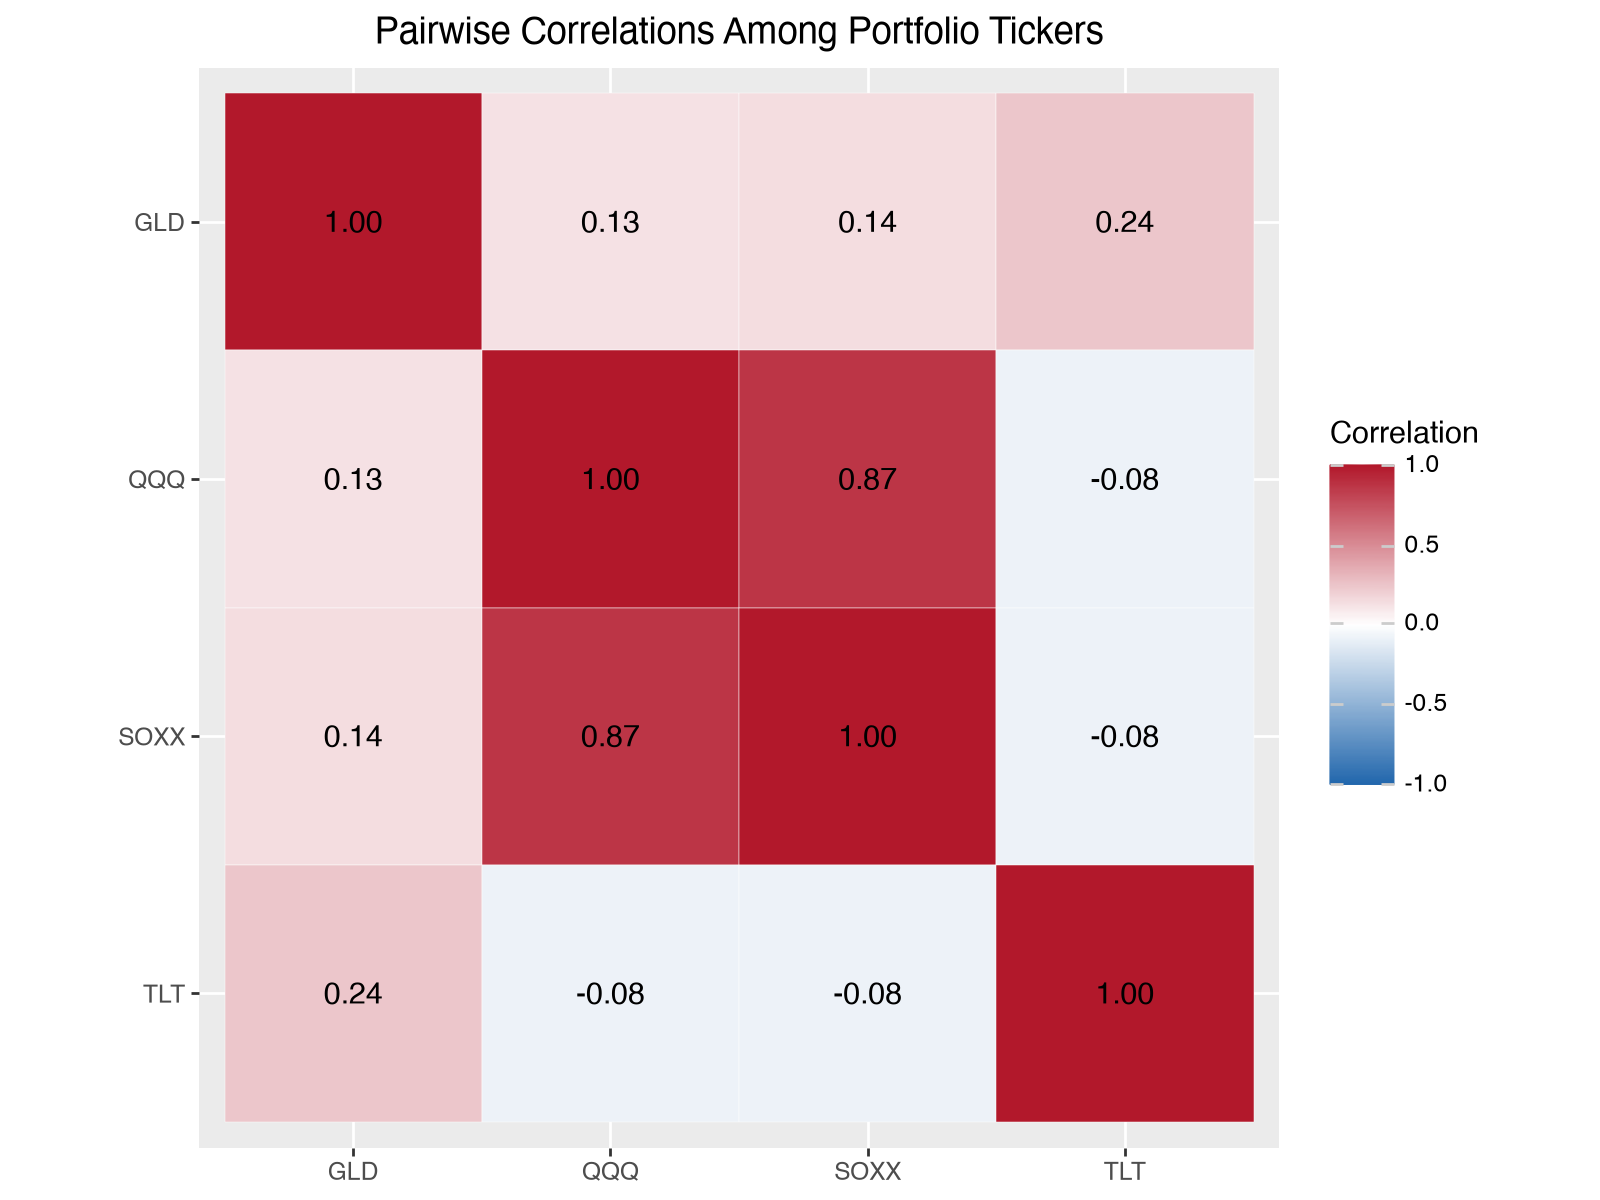

In [25]:
# Daily return correlations among the portfolio tickers
correlation = R[tickers].corr()

print("Correlation matrix:")
display(correlation.round(3))

# Plot heatmap
correlation_long = (
    correlation
    .rename_axis(index="Row", columns="Column")
    .stack()
    .rename("Correlation")
    .reset_index()
)

display(
    ggplot(correlation_long, aes("Column", "Row", fill="Correlation"))
    + geom_tile(color="white")
    + geom_text(aes(label="Correlation"), format_string="{:.2f}")
    + scale_fill_gradient2(
        low="#2166ac",
        mid="white",
        high="#b2182b",
        midpoint=0,
        limits=(-1, 1)
    )
    + scale_x_discrete(limits=tickers)
    + scale_y_discrete(limits=tickers[::-1])
    + coord_equal()
    + labs(
        title="Pairwise Correlations Among Portfolio Tickers",
        x="",
        y=""
    )
    + theme(figure_size=(8, 6))
)

## 25. SUMMARY TABLE

In [26]:
# --------------------------------------------------
# 1. Prepare clean data
# --------------------------------------------------

# Two-factor model
F_two = returns[["MKT", "HML"]].copy()

# Combine everything into one DataFrame
regression_data = pd.concat(
    [
        portfolio_returns,
        F_two,
        rf_daily.rename("RF")
    ],
    axis=1
)

# Replace infinite values with NaN
regression_data = regression_data.replace(
    [np.inf, -np.inf],
    np.nan
)

# Remove rows with missing values
regression_data = regression_data.dropna()

print(
    "Observations used in regression:",
    len(regression_data)
)


# --------------------------------------------------
# 2. Annualised portfolio return
# --------------------------------------------------

annualised_return = (
    portfolio_returns.mean()
    * trading_days
)


# --------------------------------------------------
# 3. Annualised portfolio volatility
# --------------------------------------------------

annualised_volatility = (
    portfolio_returns.std()
    * np.sqrt(trading_days)
)


# --------------------------------------------------
# 4. Two-factor regression
# --------------------------------------------------
#
# Rp - Rf =
# alpha + beta_MKT*MKT + beta_HML*HML + error
#

X = np.column_stack([
    np.ones(len(regression_data)),
    regression_data["MKT"].values,
    regression_data["HML"].values
])

regression_results = {}

for strategy in portfolio_returns.columns:

    # Excess portfolio return
    y = (
        regression_data[strategy]
        - regression_data["RF"]
    ).values

    # OLS regression
    coefficients = np.linalg.lstsq(
        X,
        y,
        rcond=None
    )[0]

    alpha_daily = coefficients[0]
    beta_mkt = coefficients[1]
    beta_hml = coefficients[2]

    # Regression residuals
    residuals = y - X @ coefficients

    # Degrees of freedom
    dof = len(y) - X.shape[1]

    # Residual variance
    residual_variance = (
        residuals @ residuals
    ) / dof

    # Variance-covariance matrix of coefficients
    XTX_inv = np.linalg.inv(X.T @ X)

    # Standard error of alpha
    alpha_se = np.sqrt(
        residual_variance * XTX_inv[0, 0]
    )

    # Alpha t-statistic
    alpha_tstat = (
        alpha_daily / alpha_se
    )

    regression_results[strategy] = {
        "Alpha": alpha_daily,
        "Beta MKT": beta_mkt,
        "Beta HML": beta_hml,
        "Alpha t-stat": alpha_tstat
    }


regression_results = pd.DataFrame(
    regression_results
).T


# --------------------------------------------------
# 5. Annualised alpha
# --------------------------------------------------

annualised_alpha = (
    regression_results["Alpha"]
    * trading_days
)


# --------------------------------------------------
# 6. Tracking Error
# --------------------------------------------------
#
# Benchmark = equal-weight portfolio
#
# TE² = (w - wb)' Σ (w - wb)
#

benchmark_weights = (
    np.ones(len(tickers))
    / len(tickers)
)

tracking_error = {}

for strategy in strategy_weights.columns:

    active_weights = (
        strategy_weights[strategy].values
        - benchmark_weights
    )

    TE_squared = (
        active_weights
        @ Sigma.values
        @ active_weights
    )

    tracking_error[strategy] = np.sqrt(
        TE_squared
    )

tracking_error = pd.Series(
    tracking_error
)


# --------------------------------------------------
# 7. CVaR
# --------------------------------------------------
#
# 95% CVaR = average loss in the worst 5%
# of observed daily portfolio returns.
#

confidence_level = 0.95

cvar = {}

for strategy in portfolio_returns.columns:

    strategy_returns = (
        portfolio_returns[strategy]
        .dropna()
    )

    var_threshold = strategy_returns.quantile(
        1 - confidence_level
    )

    worst_returns = strategy_returns[
        strategy_returns <= var_threshold
    ]

    cvar[strategy] = -worst_returns.mean()


cvar = pd.Series(cvar)


# --------------------------------------------------
# 8. Consolidated summary table
# --------------------------------------------------

summary = pd.DataFrame({

    "Annualised Return":
        annualised_return,

    "Annualised Volatility":
        annualised_volatility,

    "Alpha":
        annualised_alpha,

    "Beta MKT":
        regression_results["Beta MKT"],

    "Beta HML":
        regression_results["Beta HML"],

    "Tracking Error":
        tracking_error,

    "CVaR 95%":
        cvar,

    "Alpha t-stat":
        regression_results["Alpha t-stat"]

})


# --------------------------------------------------
# 9. Display final summary table
# --------------------------------------------------
print("Portfolio weights (rebalanced daily):")
display(strategy_weights.round(4))

print("Portfolio Strategy Comparison")
display(
    summary.style.format({
        "Annualised Return": "{:.2%}",
        "Annualised Volatility": "{:.2%}",
        "Alpha": "{:.2%}",
        "Beta MKT": "{:.3f}",
        "Beta HML": "{:.3f}",
        "Tracking Error": "{:.2%}",
        "CVaR 95%": "{:.2%}",
        "Alpha t-stat": "{:.3f}"
    })
)

Observations used in regression: 2507
Portfolio weights (rebalanced daily):


,Naive MVO,Ridge MVO,Factor Neutral
GLD,2.7709,0.3242,1.2497
QQQ,-0.1300,0.4199,0.6078
SOXX,2.0688,1.0115,-0.5631
TLT,-3.7097,-0.7556,-0.2944


Portfolio Strategy Comparison


,Annualised Return,Annualised Volatility,Alpha,Beta MKT,Beta HML,Tracking Error,CVaR 95%,Alpha t-stat
Naive MVO,108.30%,101.22%,57.30%,3.474,-1.100,91.16%,14.66%,2.437
Ridge MVO,48.70%,46.78%,17.32%,1.943,-0.900,34.58%,6.77%,2.348
Factor Neutral,10.48%,21.26%,8.07%,-0.000,-0.000,24.74%,3.17%,1.195
